<a href="https://colab.research.google.com/github/Prava0712/Electric-Vehicle-Data-Analysis/blob/main/Electric_Vehicle_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Task 1: A customer has a budget of 350,000 PLN and wants an EV with a minimum range of 400 km.
import pandas as pd
EVdata = pd.read_csv("EVdata.csv")
EVdata.head()

,Car full name,Make,Model,Minimal price (gross) [PLN],Engine power [KM],Maximum torque [Nm],Type of brakes,Drive type,Battery capacity [kWh],Range (WLTP) [km],...,Permissable gross weight [kg],Maximum load capacity [kg],Number of seats,Number of doors,Tire size [in],Maximum speed [kph],Boot capacity (VDA) [l],Acceleration 0-100 kph [s],Maximum DC charging power [kW],mean - Energy consumption [kWh/100 km]
0,Audi e-tron 55 quattro,Audi,e-tron 55 quattro,345700,360,664,disc (front + rear),4WD,95.0,438,...,3130.0,640.0,5,5,19,200,660.0,5.7,150,24.45
1,Audi e-tron 50 quattro,Audi,e-tron 50 quattro,308400,313,540,disc (front + rear),4WD,71.0,340,...,3040.0,670.0,5,5,19,190,660.0,6.8,150,23.80
2,Audi e-tron S quattro,Audi,e-tron S quattro,414900,503,973,disc (front + rear),4WD,95.0,364,...,3130.0,565.0,5,5,20,210,660.0,4.5,150,27.55
3,Audi e-tron Sportback 50 quattro,Audi,e-tron Sportback 50 quattro,319700,313,540,disc (front + rear),4WD,71.0,346,...,3040.0,640.0,5,5,19,190,615.0,6.8,150,23.30
4,Audi e-tron Sportback 55 quattro,Audi,e-tron Sportback 55 quattro,357000,360,664,disc (front + rear),4WD,95.0,447,...,3130.0,670.0,5,5,19,200,615.0,5.7,150,23.85


In [4]:
#a) Your task is to filter out EVs that meet these criteria
filtered_evs = EVdata[(EVdata["Minimal price (gross) [PLN]"] <= 350000) & (EVdata["Range (WLTP) [km]"] >= 400)]
print("EVs within budget and required range:")
print(filtered_evs[["Make", "Model", "Minimal price (gross) [PLN]",
"Range (WLTP) [km]", "Battery capacity [kWh]"]])


EVs within budget and required range:
             Make                        Model  Minimal price (gross) [PLN]  \
0            Audi            e-tron 55 quattro                       345700   
8             BMW                          iX3                       282900   
15        Hyundai          Kona electric 64kWh                       178400   
18            Kia                 e-Niro 64kWh                       167990   
20            Kia                 e-Soul 64kWh                       160990   
22  Mercedes-Benz                          EQC                       334700   
39          Tesla  Model 3 Standard Range Plus                       195490   
40          Tesla           Model 3 Long Range                       235490   
41          Tesla          Model 3 Performance                       260490   
47     Volkswagen         ID.3 Pro Performance                       155890   
48     Volkswagen                   ID.3 Pro S                       179990   
49     Volkswa

In [5]:
# b) Group them by the manufacturer (Make)
grouped = filtered_evs.groupby("Make")
print("\nNumber of EVs by Manufacturer:")
print(grouped.size())


Number of EVs by Manufacturer:
Make
Audi             1
BMW              1
Hyundai          1
Kia              2
Mercedes-Benz    1
Tesla            3
Volkswagen       3
dtype: int64


In [10]:
# c) Calculate the average battery capacity for each manufacturer.
grouped = filtered_evs.groupby("Make")["Battery capacity [kWh]"].mean().reset_index()
grouped.rename(columns={"Battery capacity [kWh]":
"Avg_Battery_Capacity_kWh"}, inplace=True)
print("\nAverage Battery Capacity per Manufacturer:")
print(grouped)



Average Battery Capacity per Manufacturer:
            Make  Avg_Battery_Capacity_kWh
0           Audi                 95.000000
1            BMW                 80.000000
2        Hyundai                 64.000000
3            Kia                 64.000000
4  Mercedes-Benz                 80.000000
5          Tesla                 68.000000
6     Volkswagen                 70.666667


In [14]:
# Task 2: You suspect some EVs have unusually high or low energyconsumption.
# Find the outliers in the mean - Energy consumption [kWh/100 km]
# column.
import pandas as pd
import numpy as np
from scipy import stats
EVdata = pd.read_csv("EVdata.csv")
consumption = EVdata["mean - Energy consumption [kWh/100 km]"]
z_scores = stats.zscore(consumption)
outliers = EVdata[np.abs(z_scores) > 3]
print("Outliers in Energy Consumption:")
print(outliers[["Make", "Model", "mean - Energy consumption [kWh/100 km]"]])

Outliers in Energy Consumption:
Empty DataFrame
Columns: [Make, Model, mean - Energy consumption [kWh/100 km]]
Index: []


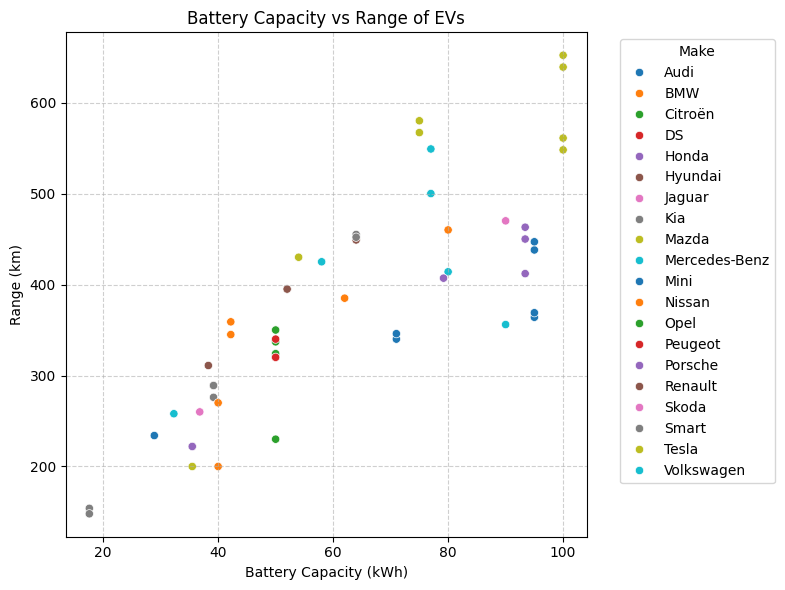

In [19]:
# Task 3: Your manager wants to know if there's a strong relationship between battery capacity and range.
# a) Create a suitable plot to visualize
# b) Highlight any insights.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
EVdata = pd.read_csv("EVdata.csv")
plt.figure(figsize=(8,6))
sns.scatterplot(
 data=EVdata,
 x="Battery capacity [kWh]",
 y="Range (WLTP) [km]",
 hue="Make",
 palette="tab10"
)
plt.title("Battery Capacity vs Range of EVs")
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Range (km)")
plt.legend(title="Make", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [21]:
# Task 4: Build an EV recommendation class. The class should allow users to input their
# budget, desired range, and battery capacity. The class should then return the top three EVs
# matching their criteria.

import pandas as pd
class EVRecommender:
    def __init__(self, data_file):
        self.df = pd.read_csv(data_file)
    def recommend(self, budget, min_range, min_battery):
        # Recommend top 3 EVs based on user input.
        filtered = self.df[
            (self.df["Minimal price (gross) [PLN]"] <= budget) &
            (self.df["Range (WLTP) [km]"] >= min_range) &
            (self.df["Battery capacity [kWh]"] >= min_battery)
        ]
        filtered = filtered.sort_values(by="Range (WLTP) [km]",
        ascending=False)
        return filtered.head(3)[["Make", "Model", "Minimal price (gross) [PLN]", "Range (WLTP) [km]", "Battery capacity [kWh]"]]
if __name__ == "__main__":
    recommender = EVRecommender("EVdata.csv")
    budget = 350000
    desired_range = 400
    desired_battery = 70
    recommendations = recommender.recommend(budget, desired_range,
desired_battery)
    print("Top 3 Recommended EVs:")
    print(recommendations)


Top 3 Recommended EVs:
          Make                Model  Minimal price (gross) [PLN]  \
40       Tesla   Model 3 Long Range                       235490   
41       Tesla  Model 3 Performance                       260490   
48  Volkswagen           ID.3 Pro S                       179990   

    Range (WLTP) [km]  Battery capacity [kWh]  
40                580                    75.0  
41                567                    75.0  
48                549                    77.0  


In [23]:
# Task 5: Inferential Statistics – Hypothesis Testing: Test whether there is a significant
# difference in the average Engine power [KM] of vehicles manufactured by two leading
# manufacturers i.e. Tesla and Audi. What insights can you draw from the test results?
# Recommendations and Conclusion: Provide actionable insights based on your analysis.
# (Conduct a two sample t-test using ttest_ind from scipy.stats module)
import pandas as pd
from scipy.stats import ttest_ind
df = pd.read_csv("EVdata.csv")
tesla_power = df[df["Make"] == "Tesla"]["Engine power [KM]"].dropna()
audi_power = df[df["Make"] == "Audi"]["Engine power [KM]"].dropna()
t_stat, p_val = ttest_ind(tesla_power, audi_power, equal_var=False)
print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_val, 4))

T-statistic: 1.794
P-value: 0.1068
